In [ ]:
import torch
import torch.nn as nn


class ScoreNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

class ScoreMatching(nn.Module):
    def __init__(self, snet, alpha, sigma, eta, D, T):
        super(ScoreMatching, self).__init__()

        print('Score Matching by JT.')

        self.snet = ScoreNet(input_dim=D)

        # other hyperparams
        self.D = D
                
        self.sigma = sigma
        
        self.T = T
        
        self.alpha = alpha
        
        self.eta = eta
    
    def sample_base(self, x_1):
        # Uniform over [-1, 1]**D
        return 2. * torch.rand_like(x_1) - 1.
    
    def langevine_dynamics(self, x):
        for t in range(self.T):
            x = x + self.alpha * self.snet(x) + self.eta * torch.randn_like(x)
        return x

    def forward(self, x, y, reduction='mean'):
        # =====Score Matching
        # sample noise
        # epsilon = torch.randn_like(x)
        epsilon = (x - y)**2
        
        # =====
        # calculate the noisy data
        tilde_x = x 

        # =====
        # calculate the score model
        s = self.snet(tilde_x)
        
        # =====LOSS: the Score Matching Loss
        SM_loss = ((s + epsilon)**2.).sum(-1) # in order to keep the Langevine dynamics unchanged, we do not use \tilde{s} = -sigma * s but we use \tilde{s} = sigma * s

        # Final LOSS
        if reduction == 'sum':
            loss = SM_loss.sum()
        else:
            loss = SM_loss.mean()

        return loss

    def sample(self,  batch_size=64):
        # sample x_0
        x = self.sample_base(torch.empty(batch_size, self.D))
        
        # run langevine dynamics
        x = self.langevine_dynamics(x)
        
        x = torch.tanh(x)
        return x

In [82]:
import netCDF4 as netcdf

# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  

In [53]:
def tweedie_formula(y, score_net, sigma):
    """
    Apply Tweedie's formula to denoise y using a score network.

    Args:
        y (torch.Tensor): Noisy input, shape [batch, D]
        score_net (nn.Module): Trained score network
        sigma (float): Noise standard deviation

    Returns:
        torch.Tensor: Denoised estimate
    """
    return y + sigma**2 * score_net(y)

In [73]:
# read data yearky in pickle file
import pickle
import sys
import os
import numpy as np
maindir = os.getcwd()
sys.path.append(maindir+"/src")

with open('data_yearly.pickle', 'rb') as f:
    data = pickle.load(f)


data_anomaly_yearly = data['dic_data_yearly']
data_forced_response_yearly = data['dic_forced_response_yearly']


In [74]:
def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = x[m]/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = y[m]/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, x[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, y[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = x[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        y_train[m] = y[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [81]:
# x_train_yearly, y_train_yearly  = merge_training_data(data_anomaly_yearly,data_forced_response_yearly,dtype=torch.float32)

# x_train_yearly = x_train_yearly.view(-1,x_train_yearly.shape[2])
# y_train_yearly = y_train_yearly.view(-1,y_train_yearly.shape[2])

x_train_yearly = data_anomaly_yearly['CESM2']
y_train_yearly = data_forced_response_yearly['CESM2']

In [ ]:
## code to generate corrupted data for each climate model
def generate_corrupted_data(data, noise_level=0.1, n_samples=10):
    """Generate corrupted data by adding Gaussian noise to the original data.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           noise_level: standard deviation of the Gaussian noise
       Return:
           corrupted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    noise = np.random.normal(0, noise_level, (n_samples, data.shape[1],data.shape[2], data.shape[3]))

    # select a random sample from the training set using an index

    corrupted_data = data[0,:,:,:] + noise
    return corrupted_data

# Generate corrupted data with shift in data
def shift_data(data, shift=0.3):
    """Shift the data by a given number of time steps.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           shift: number of time steps to shift
       Return:
           shifted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    # shifted_data = np.roll(data, shift=shift, axis=1)
    shifted_data = data + shift*np.random.choice([-1,0,1], data.shape)
    return shifted_data

corrupted_data_tmp = generate_corrupted_data(data_forced_response_yearly['CESM2'], noise_level=vars['CESM2'], n_samples=10)

print(f'Corrupted data shape: {corrupted_data_tmp.shape}')
corrupted_data_tmp = shift_data(corrupted_data_tmp)

In [76]:
# For grayscale images of shape [batch, 1, H, W]
idx_gridcell = 100

snet = ScoreNet(input_dim=x_train_yearly.shape[1], hidden_dim=128, output_dim=None)
score = snet(x_train_yearly[0,:,idx_gridcell]) 

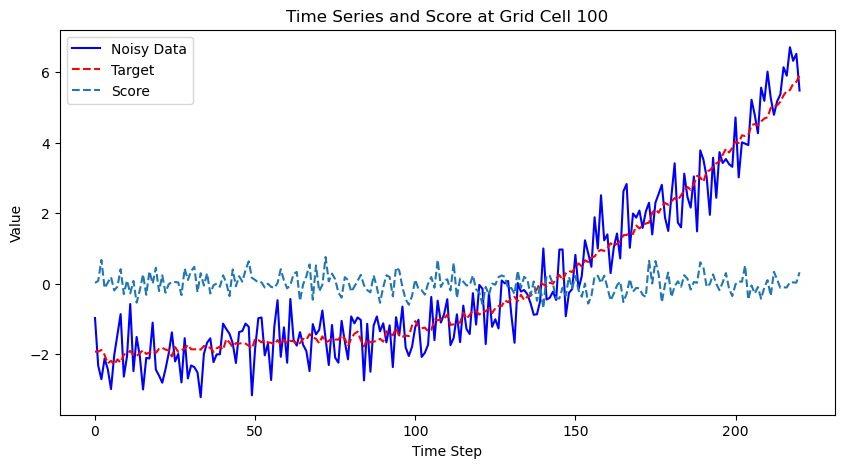

In [77]:
# plot the time series and the score
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(x_train_yearly[0,:,idx_gridcell].numpy(), label='Noisy Data', linestyle='-',color='blue')
plt.plot(y_train_yearly[0,:,idx_gridcell].numpy(), label='Target', linestyle='--', color='red')
plt.plot(score.detach().numpy(), label='Score', linestyle='--')
plt.title('Time Series and Score at Grid Cell {}'.format(idx_gridcell))
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()  

In [78]:
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train_yearly[:,:,idx_gridcell], y_train_yearly[:,:,idx_gridcell]),
    batch_size=64,
    shuffle=True,
    num_workers=4
)

In [79]:
from torch.optim import Adam

# Assume x_train is your training data of shape [batch, D]
D = x_train_yearly.shape[1]
snet = ScoreNet(input_dim=D)
sm = ScoreMatching(snet=snet, alpha=0.1, sigma=0.1, eta=0.01, D=D, T=30)

optimizer = Adam(sm.parameters(), lr=1e-2)
epochs = 100

for epoch in range(epochs):
    for batch in dataloader:  # dataloader yields batches of x_train
        print(batch[0].shape, batch[1].shape)
        x = batch[0].to(torch.float32)
        y = batch[1].to(torch.float32)
        optimizer.zero_grad()
        loss = sm(x, y, reduction='mean')  # Use the forward method of ScoreMatching
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}: Loss = {loss.item()}")

Score Matching by JT.
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 0: Loss = 109.9554672241211
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 1: Loss = 211.0594482421875
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 2: Loss = 83.81535339355469
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 3: Loss = 78.80397033691406
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 4: Loss = 76.81327819824219
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 5: Loss = 68.82914733886719
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 6: Loss = 68.18148803710938
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 7: Loss = 67.75438690185547
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 8: Loss = 68.0505142211914
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 9: Loss = 68.70993041992188
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 10: Loss = 67.79011535644531
torch.Size([50, 221]) torch.Size([50, 221])
Epoch 11: Loss = 67.50340270996094
torch.Size([50, 221]) torch.Size([50, 221

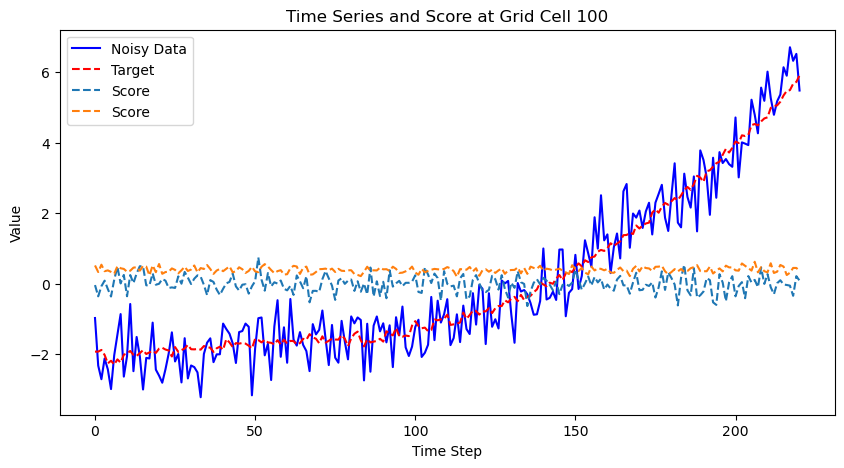

In [80]:
# check on the first sample
idx_gridcell = 100
x_sample = x_train_yearly[0,:,idx_gridcell]
score_sample = snet(x_sample)

# plot the time series and the score
plt.figure(figsize=(10, 5))
plt.plot(x_sample.numpy().flatten(), label='Noisy Data', linestyle='-', color='blue')
plt.plot(y_train_yearly[0,:,idx_gridcell].numpy(), label='Target', linestyle='--', color='red')
plt.plot(score_sample.detach().numpy().flatten(), label='Score', linestyle='--')
plt.plot(torch.mean((y_train_yearly[:,:,idx_gridcell] - x_train_yearly[:,:,idx_gridcell])**2, dim=0).detach().numpy(), label='Score', linestyle='--')
plt.title('Time Series and Score at Grid Cell {}'.format(idx_gridcell))
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

In [15]:
# test the score matching 

D = 10  # Suppose your data is D-dimensional
snet = ScoreNet(input_dim=D)
score = snet(torch.randn(32, D))  # Output: [32, D]
    
print("ScoreNet output shape:", score.shape)  # Should be [32, D]
    
sm = ScoreMatching(snet=snet, alpha=0.1, sigma=0.1, eta=0.01, D=D, T=10)
loss = sm(torch.randn(32, D))
    
print("Score Matching Loss:", loss.item())
sampled_data = sm.sample(batch_size=32)
print("Sampled data shape:", sampled_data.shape)  # Should be [32, D]
print("Sampled data:", sampled_data)

y = torch.randn(32, D)  # Example noisy data
sigma = 0.1  # Example noise standard deviation

# y: noisy data, score_net: trained ScoreNet, sigma: noise std
denoised = tweedie_formula(y, snet, sigma)

ScoreNet output shape: torch.Size([32, 10])
Score Matching by JT.
Score Matching Loss: 50.671409606933594
Sampled data shape: torch.Size([32, 10])
Sampled data: tensor([[-2.8855e-02, -7.6273e-02,  5.2141e-01,  6.6944e-01, -8.0600e-02,
         -5.3157e-01,  3.6473e-01, -6.4454e-01,  5.6136e-01,  5.9233e-01],
        [ 2.0831e-01, -3.4211e-01, -1.2437e-01,  3.2687e-01,  5.3154e-01,
          7.3285e-01,  4.9712e-01,  3.9001e-01,  8.4273e-02,  6.7001e-03],
        [ 3.4180e-01,  1.3793e-01, -7.0361e-01, -7.5317e-01, -1.6074e-01,
          8.2702e-01,  7.3153e-01,  6.3531e-01,  6.1116e-01, -7.4784e-01],
        [ 7.3370e-01,  7.0112e-01, -4.8841e-01, -4.5867e-01,  1.8087e-01,
         -2.1607e-02, -4.5598e-01, -1.0022e-01,  1.0977e-01, -6.5728e-01],
        [-4.3334e-02, -6.9190e-01, -3.1556e-01, -4.7852e-01,  5.6229e-01,
          3.2288e-01, -1.9585e-01,  6.7091e-01, -5.8877e-01,  4.7514e-01],
        [-2.2926e-01,  4.9497e-01,  7.2914e-01, -5.7315e-02, -2.8667e-01,
         -6.7647e-01

In [14]:
# 2d input
linear_layer_2d = nn.Linear(in_features=64, out_features=32)
# 1st dimension (128) = batch dimension, input 64 x 64
input_2d = torch.randn(128, 32, 64)
output_2d = linear_layer_2d(input_2d)
print(output_2d.size())

linear_layer_1d = nn.Linear(in_features=32, out_features=16)
output_1d = linear_layer_1d(output_2d.transpose(1, 2))
print(output_1d.size())  # Output shape should be [128, 16, 64]
output_1d = output_1d.transpose(1, 2)
print(output_1d.size())

torch.Size([128, 32, 32])
torch.Size([128, 32, 16])
torch.Size([128, 16, 32])


100%|██████████| 344862509/344862509 [00:02<00:00, 129355808.32it/s]


Extracting flowers-102/102flowers.tgz to flowers-102


100%|██████████| 502/502 [00:00<00:00, 623125.36it/s]


100%|██████████| 14989/14989 [00:00<00:00, 16566119.28it/s]


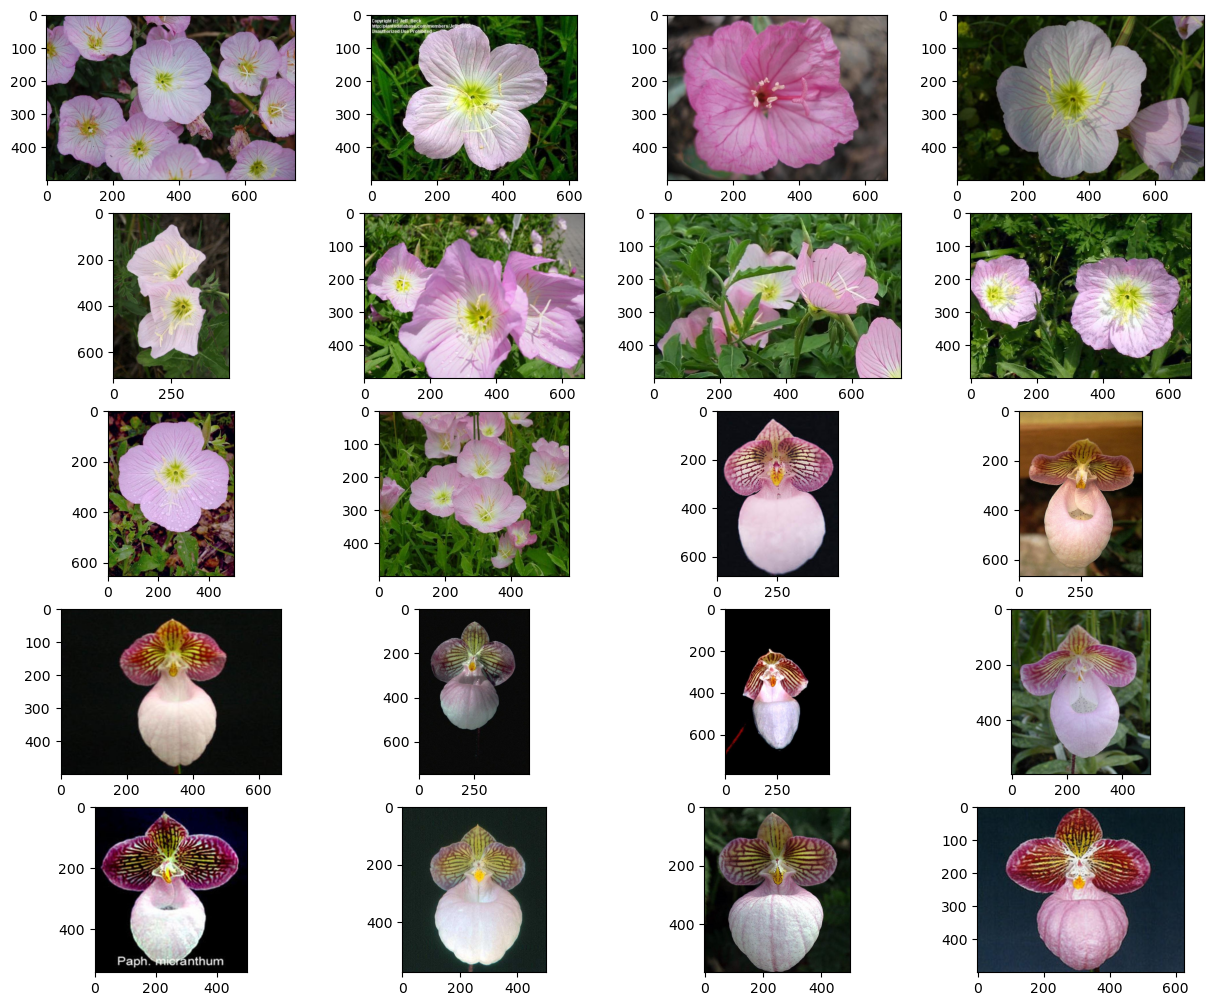

In [7]:
import torch
import torchvision
import matplotlib.pyplot as plt

def show_images(datset, num_samples=20, cols=4):
    """ Plots some samples from the dataset """
    plt.figure(figsize=(15,15)) 
    for i, img in enumerate(data):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img[0])

data = torchvision.datasets.Flowers102(root=".", download=True)
show_images(data)

In [1]:
from diffusers import DiffusionPipeline

model_id = "google/ncsnpp-ffhq-1024"

# load model and scheduler
sde_ve = DiffusionPipeline.from_pretrained(model_id)

# run pipeline in inference (sample random noise and denoise)
image = sde_ve().images[0]


# save image
image[0].save("sde_ve_generated_image.png")

model_index.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/vcohen/.cache/huggingface/hub/models--google--ncsnpp-ffhq-1024/snapshots/9f964ad575b55e4d29a4fa5fe6b6e6f51955a0f0: Error no file named diffusion_pytorch_model.safetensors found in directory /home/vcohen/.cache/huggingface/hub/models--google--ncsnpp-ffhq-1024/snapshots/9f964ad575b55e4d29a4fa5fe6b6e6f51955a0f0.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Some weights of the model checkpoint at /home/vcohen/.cache/huggingface/hub/models--google--ncsnpp-ffhq-1024/snapshots/9f964ad575b55e4d29a4fa5fe6b6e6f51955a0f0 were not used when initializing UNet2DModel: 
 ['time_proj.W']


  0%|          | 0/2000 [00:00<?, ?it/s]

/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/diffusers/models/downsampling.py:240: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(kernel, device=hidden_states.device),
/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/diffusers/models/upsampling.py:312: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(kernel, device=hidden_states.device),


KeyboardInterrupt: 

In [8]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn.functional as F

def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    """ 
    Returns a specific index t of a passed list of values vals
    while considering the batch dimension.
    """
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    """ 
    Takes an image and a timestep as input and 
    returns the noisy version of it
    """
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    # mean + variance
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)


# Define beta schedule
T = 300
betas = linear_beta_schedule(timesteps=T)

# Pre-calculate different terms for closed form
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [ ]:
from torchvision import transforms 
from torch.utils.data import DataLoader
from torchvision import datasets
import numpy as np

IMG_SIZE = 64
BATCH_SIZE = 128

def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # Scales data into [0,1] 
        transforms.Lambda(lambda t: (t * 2) - 1) # Scale between [-1, 1] 
    ]
    data_transform = transforms.Compose(data_transforms)

    train = torchvision.datasets.Flowers102(root=".", download=True, 
                                         transform=data_transform)

    test = torchvision.datasets.Flowers102(root=".", download=True, 
                                         transform=data_transform, split='test')
    return torch.utils.data.ConcatDataset([train, test])
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    # Take first image of batch
    if len(image.shape) == 4:
        image = image[0, :, :, :] 
    plt.imshow(reverse_transforms(image))

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

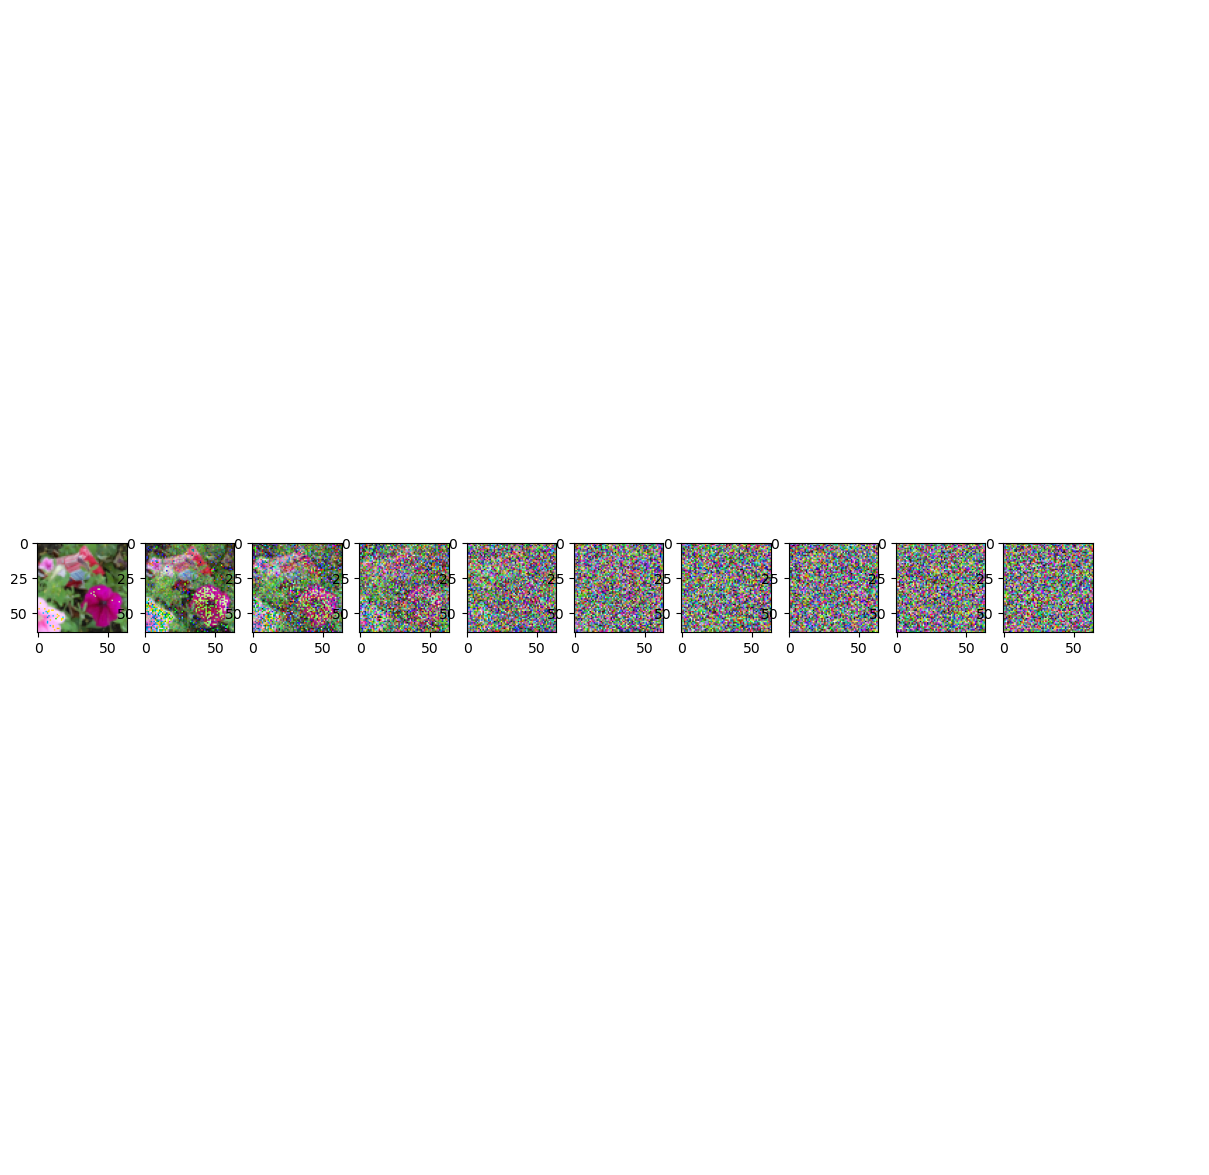

In [15]:
# Simulate forward diffusion
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = forward_diffusion_sample(image, t)
    show_tensor_image(img)

In [11]:
from torch import nn
import math


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()
        
    def forward(self, x, t, ):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # TODO: Double check the ordering here
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 3 
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )
        
        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], \
                                    time_emb_dim) \
                    for i in range(len(down_channels)-1)])
        # Upsample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], \
                                        time_emb_dim, up=True) \
                    for i in range(len(up_channels)-1)])
        
        # Edit: Corrected a bug found by Jakub C (see YouTube comment)
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embedd time
        t = self.time_mlp(timestep)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)           
            x = up(x, t)
        return self.output(x)

model = SimpleUnet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
model

Num params:  62438883


SimpleUnet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=32, out_features=128, bias=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bnorm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=32, out_features=256, bias=True)
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transfor

In [12]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)

In [13]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Calls the model to predict the noise in the image and returns 
    the denoised image. 
    Applies noise to this image, if we are not in the last step yet.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)
    
    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)
    
    if t == 0:
        # As pointed out by Luis Pereira (see YouTube comment)
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise 

@torch.no_grad()
def sample_plot_image():
    # Sample noise
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,15))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        # Edit: This is to maintain the natural range of the distribution
        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            show_tensor_image(img.detach().cpu())
    plt.show()            

Epoch 0 | step 000 Loss: 0.8082193732261658 


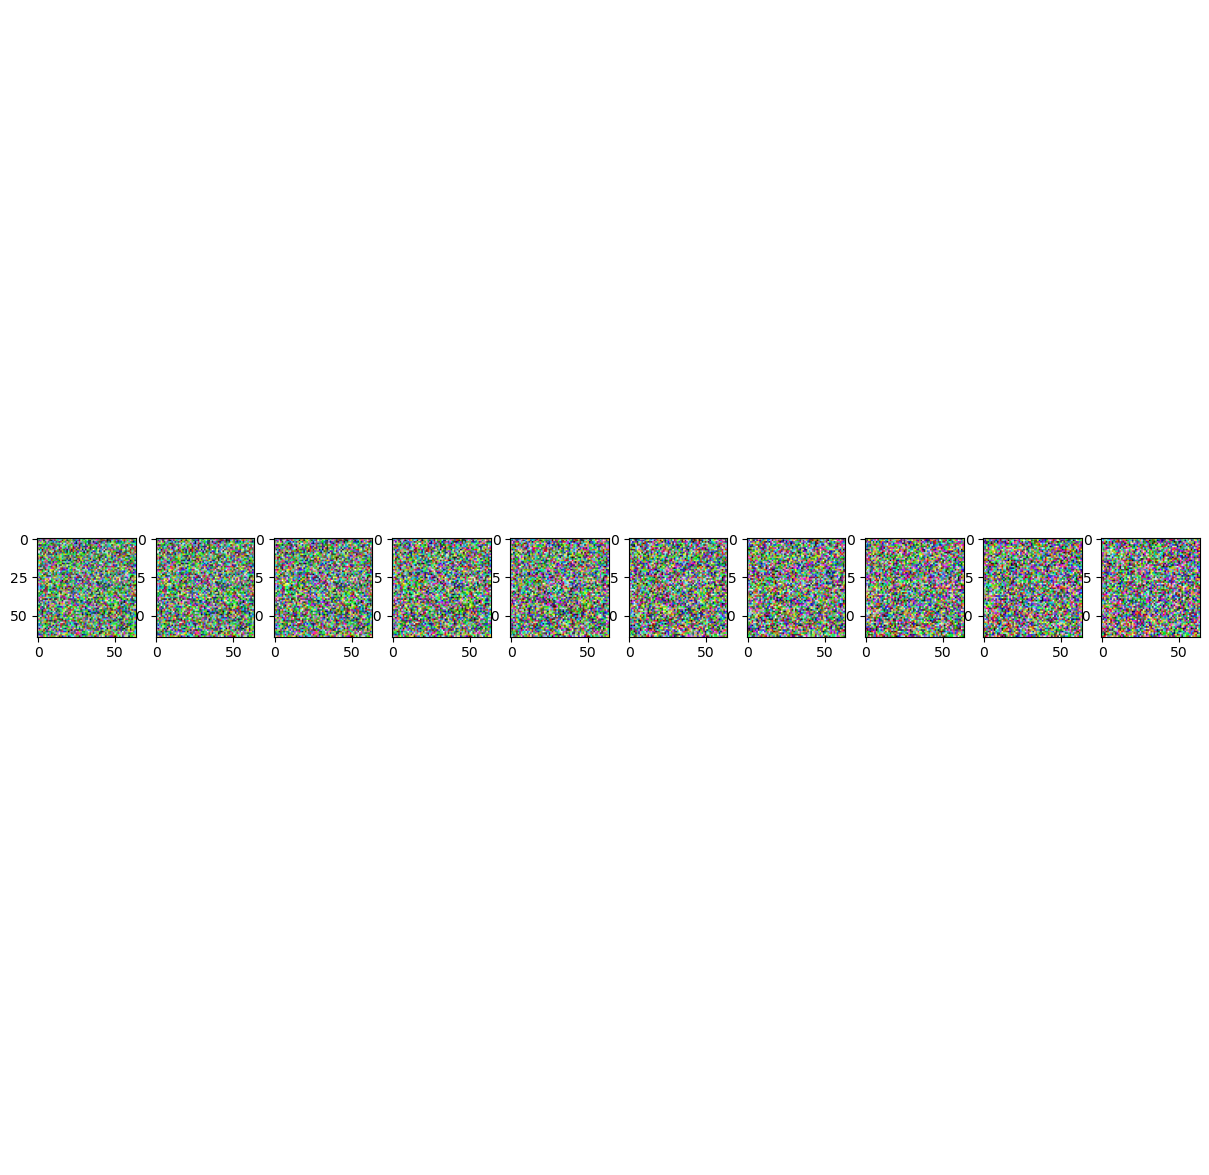

KeyboardInterrupt: 

In [14]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 100 # Try more!

for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
      optimizer.zero_grad()

      t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
      loss = get_loss(model, batch[0], t)
      loss.backward()
      optimizer.step()

      if epoch % 5 == 0 and step == 0:
        print(f"Epoch {epoch} | step {step:03d} Loss: {loss.item()} ")
        sample_plot_image()